<a href="https://colab.research.google.com/github/rebekalemooss-24/atividade-visualiza-o-01/blob/main/medallion_spark_cloudinary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pipeline Medallion (Bronze → Silver → Gold) com Spark + Cloudinary (Google Colab)

Este notebook:
1. **Puxa um dataset real** (OWID COVID-19) via HTTP.
2. Executa uma **rotina de atualização** (verifica *ETag/Last-Modified* antes de baixar).
3. Salva o arquivo bruto como **Bronze** no **Cloudinary** (*asset type: raw*).
4. Baixa o Bronze do Cloudinary, usa **Spark** para tratamento e salva **Silver** (Parquet) no Cloudinary.
5. Usa **Spark** para agregações e salva **Gold** no Cloudinary.
6. Recupera o **Gold** e gera **visualizações**.

> **Pré-requisito:** você precisa de credenciais do Cloudinary (CLOUDINARY_URL ou cloud_name/api_key/api_secret).


## 1) Instalações e imports

In [ ]:
!pip -q install cloudinary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.2 MB/s eta 0:00:00


In [ ]:
import os, json, hashlib, time
from datetime import datetime, timezone
import requests

import cloudinary
import cloudinary.uploader
import cloudinary.api

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2) Configure suas credenciais do Cloudinary

In [ ]:
cloudinary.config(
    cloud_name="",
    api_key="",
    api_secret="",
    secure=True
)

# Verificação simples:
assert os.environ.get("CLOUDINARY_URL") or cloudinary.config().cloud_name,
print("Cloudinary configurado!")

Cloudinary configurado ✔


## 3) Dataset real + rotina de atualização (ETag/Last-Modified)

In [ ]:
DATASET_URL  = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
LOCAL_DIR    = Path("/content/data")
LOCAL_CSV    = LOCAL_DIR / "owid_covid.csv"
LOCAL_META   = LOCAL_DIR / "owid_covid_meta.json"

LOCAL_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def load_meta() -> dict:
    return json.loads(LOCAL_META.read_text("utf-8")) if LOCAL_META.exists() else {}

def save_meta(meta: dict):
    LOCAL_META.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

def update_dataset(url: str, csv_path: Path) -> dict:
    meta = load_meta()

    # 1) Checa no servidor se houve mudança (ETag/Last-Modified)
    head = requests.head(url, allow_redirects=True, timeout=30)
    head.raise_for_status()
    etag = head.headers.get("ETag")
    last_modified = head.headers.get("Last-Modified")

    changed = (
        (not csv_path.exists()) or
        (etag and meta.get("etag") != etag) or
        (last_modified and meta.get("last_modified") != last_modified)
    )

    # 2) Se mudou (ou não existe), baixa e atualiza meta
    if changed:
        print("Atualização detectada. Baixando...")
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        with open(csv_path, "wb") as f:
            for chunk in r.iter_content(1024 * 1024):
                if chunk:
                    f.write(chunk)

        meta = {
            "url": url,
            "etag": etag,
            "last_modified": last_modified,
            "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
            "sha256": sha256_file(csv_path),
            "bytes": csv_path.stat().st_size,
        }
        save_meta(meta)
    else:
        print("Sem mudanças. Usando arquivo local.")

    return meta

meta = update_dataset(DATASET_URL, LOCAL_CSV)
print("CSV:", LOCAL_CSV)
print("META:", json.dumps(meta, indent=2, ensure_ascii=False))

Sem mudanças. Usando arquivo local.
CSV: /content/data/owid_covid.csv
META: {
  "etag": "W/\"7a57988ea71d49870c6d267c99bc962cdca317673544e902ffa3ae22bd6db459\"",
  "last_modified": null,
  "content_length": "9955989",
  "final_url": "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv",
  "downloaded_at_utc": "2026-02-21T03:15:31.636028+00:00",
  "sha256": "8473d0f0fdf962e1ffbd5b85b18726fc96a49bab109e271186c339725a12b10c"
}


## 4) Enviar Bronze (raw) para o Cloudinary

In [ ]:
# Convenção de paths no Cloudinary
CLOUDINARY_FOLDER = "medallion_demo"
BRONZE_PUBLIC_ID = f"{CLOUDINARY_FOLDER}/bronze/{DATASET_NAME}_latest"

# Upload como RAW (ideal para CSV/Parquet)
bronze_upload = cloudinary.uploader.upload(
    LOCAL_CSV,
    resource_type="raw",
    public_id=BRONZE_PUBLIC_ID,
    overwrite=True,
    invalidate=True,
)

bronze_url = bronze_upload.get("secure_url") or bronze_upload.get("url")
print("Bronze (Cloudinary URL):", bronze_url)

BadRequest: File size too large. Got 98391483. Maximum is 10485760. Upgrade your plan to enjoy higher limits https://www.cloudinary.com/pricing/upgrades/file-limit

In [ ]:
from pyspark.sql import SparkSession
import os
import shutil

spark = SparkSession.builder.appName("bronze_parquet").getOrCreate()

# Ler CSV
df = (spark.read
      .option("header", True)
      .option("inferSchema", True)
      .csv(str(LOCAL_CSV)))

# Escrever Parquet comprimido (Snappy)
BRONZE_PARQUET_DIR = "/content/data/bronze_parquet"

(df
 .repartition(1)
 .write
 .mode("overwrite")
 .option("compression", "snappy")
 .parquet(BRONZE_PARQUET_DIR)
)

# Compactar pasta Parquet em zip (pra upload como um único arquivo)
BRONZE_ZIP = "/content/data/bronze_parquet.zip"
shutil.make_archive(BRONZE_ZIP.replace(".zip", ""), "zip", BRONZE_PARQUET_DIR)

print("Bronze zip:", BRONZE_ZIP)
print("Tamanho zip (MB):", round(os.path.getsize(BRONZE_ZIP) / 1024 / 1024, 2))

Bronze zip: /content/data/bronze_parquet.zip
Tamanho zip (MB): 8.42


In [ ]:
CLOUDINARY_FOLDER = "medallion_demo"
BRONZE_PUBLIC_ID = f"{CLOUDINARY_FOLDER}/bronze/{DATASET_NAME}_parquet_latest"

bronze_upload = cloudinary.uploader.upload(
    BRONZE_ZIP,
    resource_type="raw",
    public_id=BRONZE_PUBLIC_ID,
    overwrite=True,
    invalidate=True,
    access_mode="public",
)

bronze_url = bronze_upload.get("secure_url") or bronze_upload.get("url")
print("Bronze Parquet (Cloudinary URL):", bronze_url)

Bronze Parquet (Cloudinary URL): https://res.cloudinary.com/dgtgz3ljz/raw/upload/v1771644337/medallion_demo/bronze/owid_covid_parquet_latest.zip


## 5) Inicializar Spark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

spark = (SparkSession.builder
         .appName("Medallion-Cloudinary")
         .getOrCreate())

spark.version

'4.0.2'

## 6) Baixar Bronze do Cloudinary e gerar Silver (tratamentos)

In [ ]:
# Agora o bronze é parquet zipado
BRONZE_ZIP_LOCAL = f"{LOCAL_DIR}/{DATASET_NAME}_bronze_from_cloudinary.zip"
BRONZE_UNZIP_DIR = f"{LOCAL_DIR}/{DATASET_NAME}_bronze_parquet_unzipped"

# 1) Baixar o ZIP do Cloudinary
r = requests.get(bronze_url, timeout=120)
r.raise_for_status()
with open(BRONZE_ZIP_LOCAL, "wb") as f:
    f.write(r.content)

print("Bronze ZIP baixado para:", BRONZE_ZIP_LOCAL, "| bytes:", os.path.getsize(BRONZE_ZIP_LOCAL))

# 2) Descompactar
Path(BRONZE_UNZIP_DIR).mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(BRONZE_ZIP_LOCAL, "r") as z:
    z.extractall(BRONZE_UNZIP_DIR)

print("Bronze extraído em:", BRONZE_UNZIP_DIR)

# 3) Ler Parquet com Spark
df_bronze = spark.read.parquet(BRONZE_UNZIP_DIR)

print("Bronze rows:", df_bronze.count(), "| cols:", len(df_bronze.columns))
df_bronze.printSchema()
df_bronze.show(5, truncate=False)

Bronze ZIP baixado para: /content/data/owid_covid_bronze_from_cloudinary.zip | bytes: 8834204
Bronze extraído em: /content/data/owid_covid_bronze_parquet_unzipped
Bronze rows: 429435 | cols: 67
root
 |-- iso_code: string (nullable = true)
 |-- continent: string (nullable = true)
 |-- location: string (nullable = true)
 |-- date: date (nullable = true)
 |-- total_cases: integer (nullable = true)
 |-- new_cases: integer (nullable = true)
 |-- new_cases_smoothed: double (nullable = true)
 |-- total_deaths: integer (nullable = true)
 |-- new_deaths: integer (nullable = true)
 |-- new_deaths_smoothed: double (nullable = true)
 |-- total_cases_per_million: double (nullable = true)
 |-- new_cases_per_million: double (nullable = true)
 |-- new_cases_smoothed_per_million: double (nullable = true)
 |-- total_deaths_per_million: double (nullable = true)
 |-- new_deaths_per_million: double (nullable = true)
 |-- new_deaths_smoothed_per_million: double (nullable = true)
 |-- reproduction_rate: doub

In [ ]:
# Tratamentos (Silver):
# - Selecionar colunas relevantes
# - Normalizar datas
# - Remover linhas sem país (location)
# - Garantir tipos numéricos em alguns campos
selected = [
    "iso_code", "continent", "location", "date",
    "total_cases", "new_cases", "total_deaths", "new_deaths",
    "people_vaccinated", "people_fully_vaccinated",
    "population"
]

df_silver = (df_bronze
    .select(*[c for c in selected if c in df_bronze.columns])
    .withColumn("date", F.to_date("date"))
    .filter(F.col("location").isNotNull())
    .withColumn("location", F.trim(F.col("location")))
)

# Garantir tipos numéricos (onde existir)
for c in ["total_cases","new_cases","total_deaths","new_deaths","people_vaccinated","people_fully_vaccinated","population"]:
    if c in df_silver.columns:
        df_silver = df_silver.withColumn(c, F.col(c).cast("double"))

# Dedupe por (location,date) se necessário
df_silver = df_silver.dropDuplicates(["location", "date"])

print("Silver rows:", df_silver.count(), " cols:", len(df_silver.columns))
df_silver.show(5, truncate=False)

SILVER_DIR = f"{LOCAL_DIR}/silver_parquet"
(df_silver
  .repartition(1)
  .write.mode("overwrite")
  .parquet(SILVER_DIR))

print("Silver Parquet salvo em:", SILVER_DIR)

Silver rows: 421665  cols: 11
+--------+---------+-----------+----------+-----------+---------+------------+----------+-----------------+-----------------------+-----------+
|iso_code|continent|location   |date      |total_cases|new_cases|total_deaths|new_deaths|people_vaccinated|people_fully_vaccinated|population |
+--------+---------+-----------+----------+-----------+---------+------------+----------+-----------------+-----------------------+-----------+
|AFG     |Asia     |Afghanistan|2020-01-05|0.0        |0.0      |0.0         |0.0       |NULL             |NULL                   |4.1128772E7|
|AFG     |Asia     |Afghanistan|2020-01-08|0.0        |0.0      |0.0         |0.0       |NULL             |NULL                   |4.1128772E7|
|AFG     |Asia     |Afghanistan|2020-01-10|0.0        |0.0      |0.0         |0.0       |NULL             |NULL                   |4.1128772E7|
|AFG     |Asia     |Afghanistan|2020-01-11|0.0        |0.0      |0.0         |0.0       |NULL             

### Upload do Silver (Parquet) para o Cloudinary

In [ ]:
import glob, shutil

# Spark escreveu uma pasta com part-*.parquet. Vamos compactar para upload como um único arquivo.
SILVER_ZIP = f"{LOCAL_DIR}/silver_{DATASET_NAME}.zip"
shutil.make_archive(SILVER_ZIP.replace(".zip",""), 'zip', SILVER_DIR)

SILVER_PUBLIC_ID = f"{CLOUDINARY_FOLDER}/silver/{DATASET_NAME}_silver_parquet_zip_latest"
silver_upload = cloudinary.uploader.upload(
    SILVER_ZIP,
    resource_type="raw",
    public_id=SILVER_PUBLIC_ID,
    overwrite=True,
    invalidate=True,
)
silver_url = silver_upload.get("secure_url") or silver_upload.get("url")
print("Silver (Cloudinary URL):", silver_url)

Silver (Cloudinary URL): https://res.cloudinary.com/dgtgz3ljz/raw/upload/v1771645599/medallion_demo/silver/owid_covid_silver_parquet_zip_latest.zip


## 7) Gold (agregações) com Spark + salvar no Cloudinary

In [ ]:
# Exemplo de camada Gold:
# - Série temporal agregada por país: casos, mortes, vacinação
# - Criação de métricas: letalidade acumulada (deaths / cases), % vacinada

df_gold = (df_silver
    .withColumn("case_fatality_ratio", F.when(F.col("total_cases") > 0, F.col("total_deaths")/F.col("total_cases")).otherwise(F.lit(None)))
    .withColumn("pct_people_vaccinated", F.when(F.col("population") > 0, F.col("people_vaccinated")/F.col("population")).otherwise(F.lit(None)))
    .withColumn("pct_people_fully_vaccinated", F.when(F.col("population") > 0, F.col("people_fully_vaccinated")/F.col("population")).otherwise(F.lit(None)))
)

# Gold "wide" (por país e data)
GOLD_DIR = f"{LOCAL_DIR}/gold_parquet"
(df_gold
  .repartition(1)
  .write.mode("overwrite")
  .parquet(GOLD_DIR))

# Também vamos gerar um Gold resumido (último registro por país)
w = F.window("date", "100000 days")

df_gold_latest = (df_gold
    .groupBy("location")
    .agg(
        F.max("date").alias("latest_date"),
        F.max("total_cases").alias("total_cases_latest"),
        F.max("total_deaths").alias("total_deaths_latest"),
        F.max("pct_people_vaccinated").alias("pct_vaccinated_latest"),
        F.max("pct_people_fully_vaccinated").alias("pct_fully_vaccinated_latest"),
        F.max("case_fatality_ratio").alias("cfr_latest"),
    )
    .orderBy(F.desc("total_cases_latest"))
)

GOLD_LATEST_CSV = f"{LOCAL_DIR}/gold_latest_by_country.csv"
(df_gold_latest
    .coalesce(1)
    .write.mode("overwrite")
    .option("header", True)
    .csv(f"{LOCAL_DIR}/gold_latest_by_country_csv_tmp"))

# mover o part-*.csv para um caminho fixo
part_files = glob.glob(f"{LOCAL_DIR}/gold_latest_by_country_csv_tmp/part-*.csv")
assert part_files, "Não encontrei o CSV do gold_latest."
shutil.copy(part_files[0], GOLD_LATEST_CSV)

print("Gold Parquet salvo em:", GOLD_DIR)
print("Gold Latest CSV salvo em:", GOLD_LATEST_CSV)
df_gold_latest.show(10, truncate=False)

Gold Parquet salvo em: /content/data/gold_parquet
Gold Latest CSV salvo em: /content/data/gold_latest_by_country.csv
+-------------+-----------+------------------+-------------------+---------------------+---------------------------+--------------------+
|location     |latest_date|total_cases_latest|total_deaths_latest|pct_vaccinated_latest|pct_fully_vaccinated_latest|cfr_latest          |
+-------------+-----------+------------------+-------------------+---------------------+---------------------------+--------------------+
|World        |2024-08-14 |7.75866783E8      |7057132.0          |0.7061052766143484   |0.6492632938898837         |1.5                 |
|Asia         |2024-08-14 |3.01499099E8      |1637249.0          |0.7814317664697498   |0.7332798867803019         |0.04230960264900662 |
|Europe       |2024-08-14 |2.52916868E8      |2102483.0          |0.7032879165472438   |0.6629244511285014         |3.0                 |
|North America|2024-08-04 |1.24492666E8      |1671178.0

In [ ]:
# Upload do Gold (Parquet compactado) + Gold Latest CSV
GOLD_ZIP = f"{LOCAL_DIR}/gold_{DATASET_NAME}.zip"
shutil.make_archive(GOLD_ZIP.replace(".zip",""), 'zip', GOLD_DIR)

GOLD_PUBLIC_ID = f"{CLOUDINARY_FOLDER}/gold/{DATASET_NAME}_gold_parquet_zip_latest"
gold_upload = cloudinary.uploader.upload(
    GOLD_ZIP,
    resource_type="raw",
    public_id=GOLD_PUBLIC_ID,
    overwrite=True,
    invalidate=True,
)
gold_url = gold_upload.get("secure_url") or gold_upload.get("url")
print("Gold Parquet ZIP (Cloudinary URL):", gold_url)

GOLD_LATEST_PUBLIC_ID = f"{CLOUDINARY_FOLDER}/gold/{DATASET_NAME}_gold_latest_by_country_csv_latest"
gold_latest_upload = cloudinary.uploader.upload(
    GOLD_LATEST_CSV,
    resource_type="raw",
    public_id=GOLD_LATEST_PUBLIC_ID,
    overwrite=True,
    invalidate=True,
)
gold_latest_url = gold_latest_upload.get("secure_url") or gold_latest_upload.get("url")
print("Gold Latest CSV (Cloudinary URL):", gold_latest_url)

Gold Parquet ZIP (Cloudinary URL): https://res.cloudinary.com/dgtgz3ljz/raw/upload/v1771645626/medallion_demo/gold/owid_covid_gold_parquet_zip_latest.zip
Gold Latest CSV (Cloudinary URL): https://res.cloudinary.com/dgtgz3ljz/raw/upload/v1771645627/medallion_demo/gold/owid_covid_gold_latest_by_country_csv_latest.csv


## 8) Recuperar Gold e gerar visualizações

In [ ]:
# Baixar o Gold Latest (CSV) do Cloudinary e visualizar com pandas/matplotlib
GOLD_LATEST_LOCAL_FROM_CLOUD = f"{LOCAL_DIR}/gold_latest_by_country_from_cloudinary.csv"

r = requests.get(gold_latest_url, timeout=120)
r.raise_for_status()
with open(GOLD_LATEST_LOCAL_FROM_CLOUD, "wb") as f:
    f.write(r.content)

gold_latest_pd = pd.read_csv(GOLD_LATEST_LOCAL_FROM_CLOUD)
gold_latest_pd.head()

,location,latest_date,total_cases_latest,total_deaths_latest,pct_vaccinated_latest,pct_fully_vaccinated_latest,cfr_latest
0,World,2024-08-14,775866783.0,7057132.0,0.706105,0.649263,1.500000
1,Asia,2024-08-14,301499099.0,1637249.0,0.781432,0.733280,0.042310
2,Europe,2024-08-14,252916868.0,2102483.0,0.703288,0.662924,3.000000
3,North America,2024-08-04,124492666.0,1671178.0,0.763860,0.657135,0.065582
4,United States,2024-08-04,103436829.0,1193165.0,0.798804,0.681774,0.061234


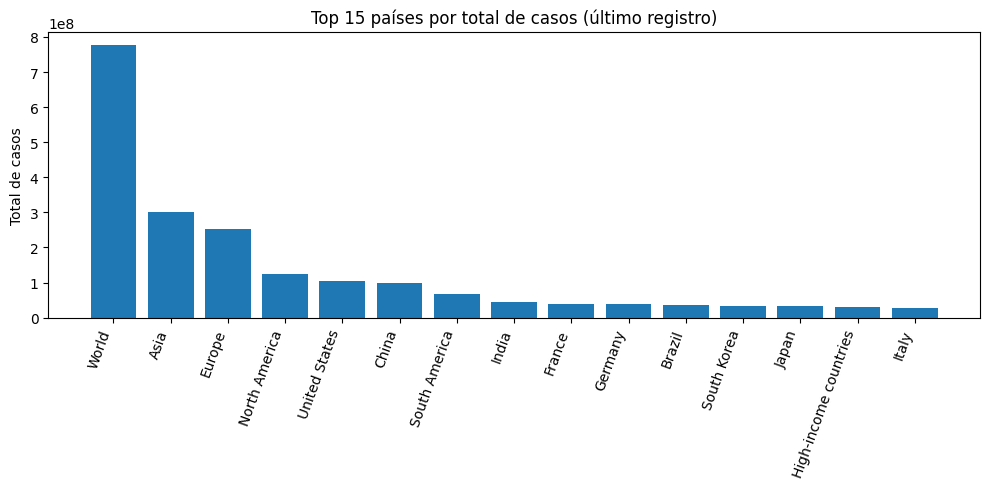

In [ ]:
# Top 15 países por total de casos
top = gold_latest_pd.sort_values("total_cases_latest", ascending=False).head(15)

plt.figure(figsize=(10,5))
plt.bar(top["location"], top["total_cases_latest"])
plt.xticks(rotation=70, ha="right")
plt.title("Top 15 países por total de casos (último registro)")
plt.ylabel("Total de casos")
plt.tight_layout()
plt.show()

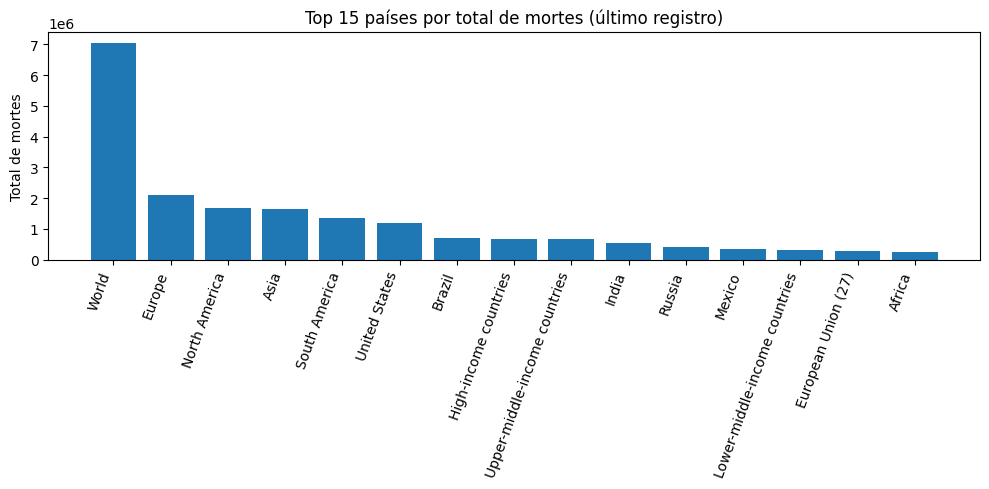

In [ ]:
# Top 15 países por total de mortes
top = gold_latest_pd.sort_values("total_deaths_latest", ascending=False).head(15)

plt.figure(figsize=(10,5))
plt.bar(top["location"], top["total_deaths_latest"])
plt.xticks(rotation=70, ha="right")
plt.title("Top 15 países por total de mortes (último registro)")
plt.ylabel("Total de mortes")
plt.tight_layout()
plt.show()

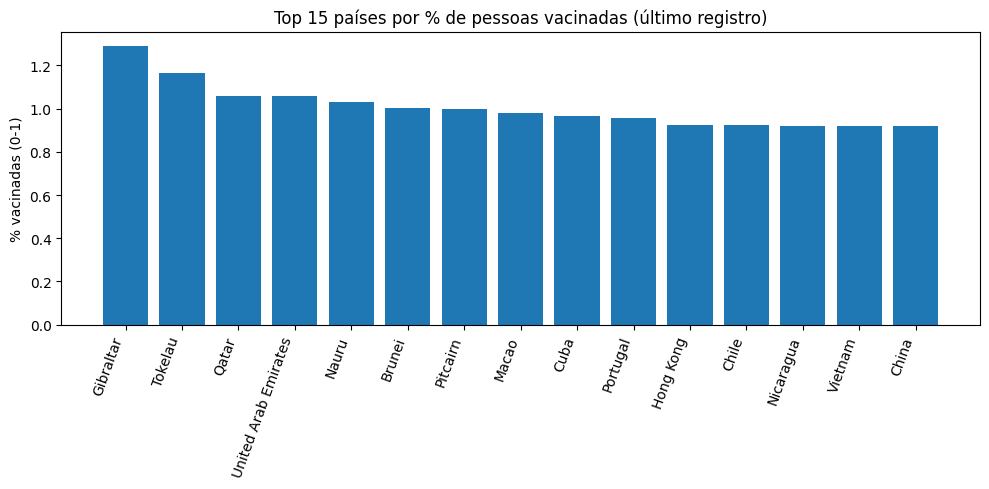

In [ ]:
# Vacinação: países com maior % vacinada (filtra valores válidos)
vacc = gold_latest_pd.dropna(subset=["pct_vaccinated_latest"]).sort_values("pct_vaccinated_latest", ascending=False).head(15)

plt.figure(figsize=(10,5))
plt.bar(vacc["location"], vacc["pct_vaccinated_latest"])
plt.xticks(rotation=70, ha="right")
plt.title("Top 15 países por % de pessoas vacinadas (último registro)")
plt.ylabel("% vacinadas (0-1)")
plt.tight_layout()
plt.show()

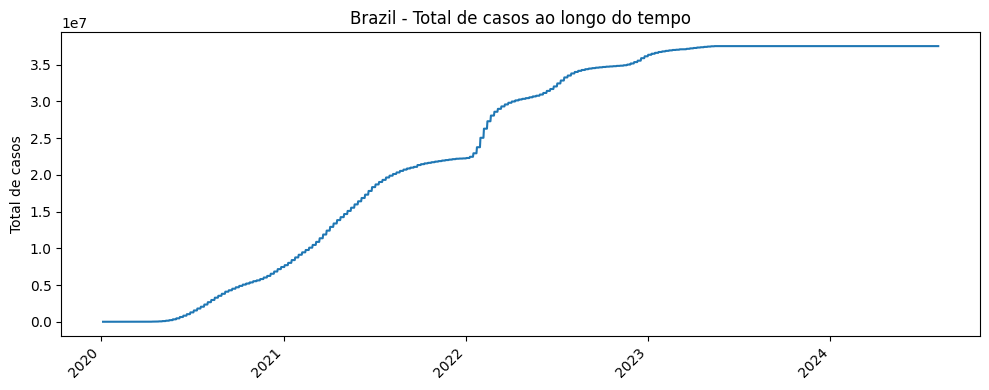

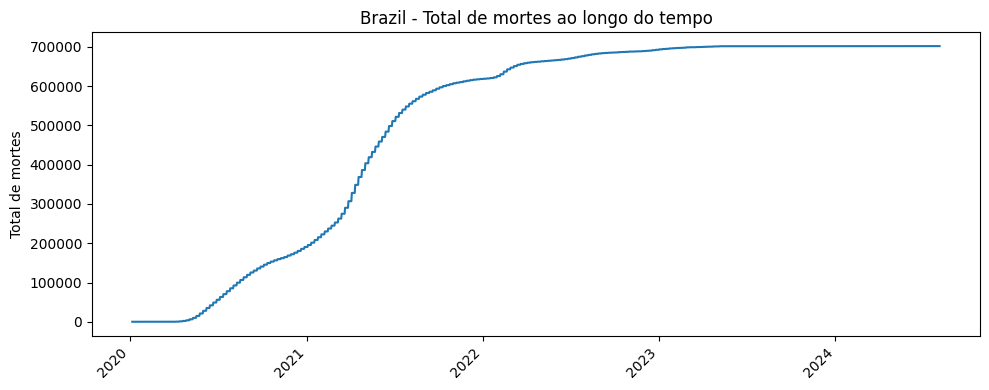

In [ ]:
# Ler o Gold Parquet ZIP: baixa, descompacta e carrega com Spark para análises temporais
GOLD_ZIP_LOCAL_FROM_CLOUD = f"{LOCAL_DIR}/gold_parquet_from_cloudinary.zip"
GOLD_UNZIP_DIR = f"{LOCAL_DIR}/gold_parquet_from_cloudinary_unzipped"

r = requests.get(gold_url, timeout=120)
r.raise_for_status()
with open(GOLD_ZIP_LOCAL_FROM_CLOUD, "wb") as f:
    f.write(r.content)

import zipfile
Path(GOLD_UNZIP_DIR).mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(GOLD_ZIP_LOCAL_FROM_CLOUD, 'r') as z:
    z.extractall(GOLD_UNZIP_DIR)

df_gold_from_cloud = spark.read.parquet(GOLD_UNZIP_DIR)

# Exemplo: curva de casos acumulados para um país (Brasil)
country = "Brazil"
series = (df_gold_from_cloud
          .filter(F.col("location") == country)
          .select("date", "total_cases", "total_deaths")
          .orderBy("date"))

series_pd = series.toPandas()

plt.figure(figsize=(10,4))
plt.plot(series_pd["date"], series_pd["total_cases"])
plt.title(f"{country} - Total de casos ao longo do tempo")
plt.ylabel("Total de casos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(series_pd["date"], series_pd["total_deaths"])
plt.title(f"{country} - Total de mortes ao longo do tempo")
plt.ylabel("Total de mortes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()